In [299]:
import pandas as pd 
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import datetime
from tqdm.auto import tqdm

def match_dfs_with_rolling_window(article_df, city_df, article_vecs, city_vecs):
    ## moving window
    city_to_article_max_index_scores = []
    article_to_city_max_index_scores = []
    
    start = max(city_df['date'].min(), article_df['date'].min())
    end = min(city_df['date'].max(), article_df['date'].max())
    for d in tqdm(pd.date_range(start, end)):
        city_council_idxs = (
            city_df
            .loc[lambda df: (df['date'] >= d) & (df['date'] < (d + datetime.timedelta(days=1)))].index
        )
        article_idxs = (
            article_df
            .loc[lambda df: (df['date'] >= d) & (df['date'] < (d + datetime.timedelta(days=7)))].index
        )

        if (len(city_council_idxs) > 0) and (len(article_idxs) > 0):
            sims = cosine_similarity(city_vecs[city_council_idxs], article_vecs[article_idxs])
            sim_df = pd.DataFrame(sims, index=city_council_idxs, columns=article_idxs)
            city_to_article_max_index_scores += (pd.concat([
                                                        sim_df.idxmax(axis=1).to_frame('article_idx'), 
                                                        sim_df.max(axis=1).to_frame('score')
                                                    ], axis=1)
                                                     .reset_index()
                                                     .rename(columns={'index': 'city_idx'})
                                                     .to_dict(orient='records')
                                                    )

            article_to_city_max_index_scores += (pd.concat([
                                                        sim_df.idxmax(axis=0).to_frame('city_idx'), 
                                                        sim_df.max(axis=0).to_frame('score')
                                                    ], axis=1)
                                                     .reset_index()
                                                     .rename(columns={'index': 'article_idx'})
                                                     .to_dict(orient='records')
                                                    )
            
    city_to_article_matching_df = pd.DataFrame(city_to_article_max_index_scores)
    article_to_city_matching_df = pd.DataFrame(article_to_city_max_index_scores)

    article_to_city_matching_df = (article_to_city_matching_df
         .assign(city_idx_and_score=lambda df: df.apply(lambda x: (x['city_idx'], x['score']), axis=1))
         .groupby('article_idx')['city_idx_and_score']
         .apply(lambda x: max(x, key=lambda y: y[0]))
         .reset_index()
         .assign(city_idx=lambda df: df['city_idx_and_score'].str.get(0).astype(int))
         .assign(score=lambda df: df['city_idx_and_score'].str.get(1))
         .drop('city_idx_and_score', axis=1)
         .merge(city_council_meeting_minutes[['text']], left_on='city_idx', right_index=True)
    )            
            
    return article_to_city_matching_df, city_to_article_matching_df

# Read in Data

In [4]:
import pandas as pd 
city_council_meeting_minutes = (
    pd.read_json(
        '../data/city-council-meeting-minutes/minutes/city-council-processed.jsonl.gz',
        compression='gzip',
        lines=True
    )
      .assign(data=lambda df: df.apply(lambda x: x['pdf_data'] if isinstance(x['data'], float) else x['data'], axis=1))
      .drop('pdf_data', axis=1)
      .assign(date=lambda df: pd.to_datetime(df['date']))
      .sort_values('date').reset_index(drop=True)
      .assign(text=lambda df: df['data'].str.join('\n'))
)

In [25]:
sfchron_article_df = (
    pd.read_json('../modeling/data/sfchron-homepage-placement-no-article-filter.jsonl', lines=True)
    .assign(date=lambda df: 
           df['homepage_key'].pipe(lambda s: pd.to_datetime(s, format='%Y%m%d%H%M%S'))
           )
)

In [223]:
articles_to_include_by_text = sfchron_article_df['article_text'].value_counts().loc[lambda s: s < 230].index
sfchron_article_df = (
    sfchron_article_df
    .loc[lambda df: df['article_text'].isin(articles_to_include_by_text)]
    .reset_index(drop=True)
)

# Train CountVectorizer

# Try Word Matching

In [226]:
cv_city_council = CountVectorizer(min_df=.0001, max_df=.4, stop_words='english')
cv_city_council.fit(city_council_meeting_minutes['text'])

CountVectorizer(max_df=0.4, min_df=0.0001, stop_words='english')

In [227]:
cv_articles = CountVectorizer(min_df=.0001, max_df=.4, stop_words='english')
cv_articles.fit(sfchron_article_df['article_text'])

CountVectorizer(max_df=0.4, min_df=0.0001, stop_words='english')

In [228]:
combined_vocabulary = set(cv_city_council.vocabulary_.keys()) & set(cv_articles.vocabulary_.keys())

In [229]:
combined_cv = CountVectorizer(vocabulary=list(combined_vocabulary))
article_vecs = combined_cv.transform(sfchron_article_df['article_text'])
city_council_vecs = combined_cv.transform(city_council_meeting_minutes['text'])

In [ ]:
article_to_city_matching_df, city_to_article_matching_df = match_dfs_with_rolling_window(
    sfchron_article_df, city_council_meeting_minutes, article_vecs, city_council_vecs
)

<AxesSubplot:>

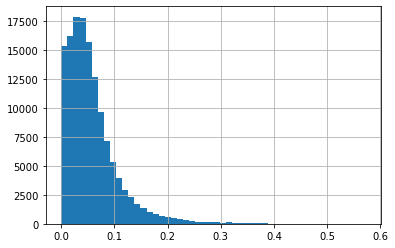

In [244]:
article_to_city_matching_df['score'].hist(bins=50)

<AxesSubplot:>

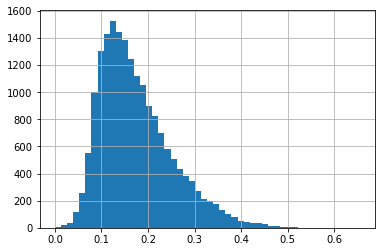

In [245]:
city_to_article_matching_df['score'].hist(bins=50)

In [264]:
sfchron_city_article_df = (
    sfchron_article_df
     .merge(article_to_city_matching_df, right_on='article_idx', left_index=True)
     .loc[lambda df: df['score'] > .1]
)

# Try LDA

In [268]:
import scipy.sparse

In [270]:
stacked_vecs = scipy.sparse.vstack([article_vecs, city_council_vecs])

In [271]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=20)
lda.fit(stacked_vecs)

LatentDirichletAllocation(n_components=20)

In [274]:
topic_matrix = pd.DataFrame(
    lda.exp_dirichlet_component_,
    columns=pd.Series({v:k for k,v in combined_cv.vocabulary_.items()}).sort_index().values
).T

In [276]:
topic_df = {}
for topic_i in topic_matrix.columns:
    topic_df[topic_i] = topic_matrix[topic_i].sort_values(ascending=False).head(5).index

In [277]:
pd.DataFrame(topic_df).rename(columns=lambda x: 'topic %s' % x)

,topic 0,topic 1,topic 2,topic 3,topic 4,topic 5,topic 6,topic 7,topic 8,topic 9,topic 10,topic 11,topic 12,topic 13,topic 14,topic 15,topic 16,topic 17,topic 18,topic 19
0,oakland,bay,police,trump,building,warriors,commissioner,county,2017,percent,2021,image,family,world,water,wine,game,school,restaurant,ordinance
1,view,park,function,president,center,game,councilmember,supervisors,calif,million,2022,art,home,says,lake,valley,giants,students,food,415
2,recommendation,area,court,house,streets,golden,clara,supervisor,image,housing,speak,music,life,way,pg,wines,team,bart,chef,county
3,alameda,county,law,election,mission,nba,santa,000,santa,000,2020,festival,long,story,national,tasting,season,hayward,menu,shall
4,councilmember,beach,var,campaign,children,oakland,manager,vote,rosa,company,cupertino,2017,old,company,park,napa,49ers,work,chicken,554


In [278]:
article_topics = lda.transform(article_vecs)
city_meeting_minutes_topics = lda.transform(city_council_vecs)

In [300]:
article_to_city_topic_matching_df, city_council_topic_matching_df = match_dfs_with_rolling_window(
    sfchron_article_df, city_council_meeting_minutes, article_topics, city_meeting_minutes_topics
)

  0%|          | 0/2485 [00:00<?, ?it/s]

<AxesSubplot:>

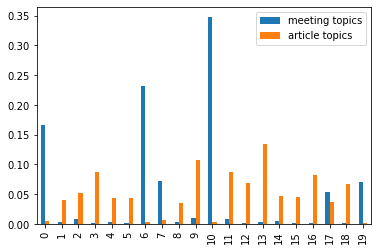

In [331]:
pd.concat([
    pd.DataFrame(city_meeting_minutes_topics).mean(axis=0).to_frame('meeting topics'),
    pd.DataFrame(article_topics).mean(axis=0).to_frame('article topics')
], axis=1).plot(kind='bar')

In [333]:
ls ../modeling/data/

latimes-homepage-placement-labeling-no-article-filter.jsonl
latimes-homepage-placement-labeling-normed.jsonl
latimes-homepage-placement-labeling.jsonl
sfchron-homepage-placement-no-article-filter.jsonl


In [336]:
(article_to_city_topic_matching_df
 .drop('text', axis=1)
 .merge(sfchron_article_df, left_on='article_idx', right_index=True)
 .to_json('../modeling/data/sfchron-homepage-placement-with-topic-matches.jsonl', lines=True, orient='records')
)